# Living Planet Index - Data Profiling Notebook

This notebook helps prepare insights for the dataset explorer by:
- previewing and visualizing the data
- generating descriptive statistics
- listing unique values for each column
- exporting reusable profiling files for the explorer

Outputs created by this notebook:
- `living-planet-index-profile.json` (statistics + unique values per column)
- `living-planet-index-all-unique-values.json` (full unique values, grouped by column)
- `living-planet-index-all-unique-values.csv` (full unique values in long-table format)

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
# Paths
project_root = Path.cwd().parent
csv_path = project_root / 'data' / 'public-datasets' / 'living-planet-index.csv'
output_dir = project_root / 'documentation' / 'dataset-profiles'
output_dir.mkdir(parents=True, exist_ok=True)

csv_path

PosixPath('/Users/mjdiepeveen/Documents/sciencedisco/wwf-discovery-day/data/public-datasets/living-planet-index.csv')

In [3]:
# Load data and normalize missing markers
df = pd.read_csv(csv_path, na_values=['NULL'])

print(f'Rows: {df.shape[0]:,}')
print(f'Columns: {df.shape[1]:,}')
df.head()

Rows: 11,067
Columns: 94


,ID,Binomial,Reference,Class,Order,Family,Genus,Species,Subspecies,Authority,...,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015
0,4,Copsychus_sechellarum,"{Komdeur, 1996 #990}",Aves,Passeriformes,Muscicapidae,Copsychus,sechellarum,NaN,"Newton, 1865",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,5,Falco_punctatus,"{Groombridge, 2001 #987}",Aves,Falconiformes,Falconidae,Falco,punctatus,NaN,"Temminck, 1821",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,6,Pternistis_ochropectus,"{WPA/Birdlife/ SSC Partridge, 2000 #1450}",Aves,Galliformes,Phasianidae,Pternistis,ochropectus,NaN,"Dorst & Jouanin, 1952",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,7,Gyps_coprotheres,"{WWF-SA, 2000 #1184}",Aves,Falconiformes,Accipitridae,Gyps,coprotheres,NaN,"(Forster, 1798)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8,Gyps_coprotheres,"{WWF-SA, 2000 #1184}",Aves,Falconiformes,Accipitridae,Gyps,coprotheres,NaN,"(Forster, 1798)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Column groups
year_cols = [c for c in df.columns if c.isdigit()]
meta_cols = [c for c in df.columns if c not in year_cols]

print(f'Metadata columns: {len(meta_cols)}')
print(f'Year columns: {len(year_cols)} ({min(year_cols)}-{max(year_cols)})')

Metadata columns: 28
Year columns: 66 (1950-2015)


In [5]:
# Basic missingness overview
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_summary = pd.DataFrame({
    'missing_pct': missing_pct.round(2),
    'non_null_count': df.notna().sum(),
    'dtype': df.dtypes.astype(str)
})

missing_summary.head(20)

,missing_pct,non_null_count,dtype
1950,98.59,156,float64
1951,98.72,142,float64
1952,98.47,169,float64
1953,98.44,173,float64
1954,98.40,177,float64
1955,98.30,188,float64
1956,98.02,219,float64
1957,98.28,190,float64
1958,97.98,224,float64
1959,97.58,268,float64


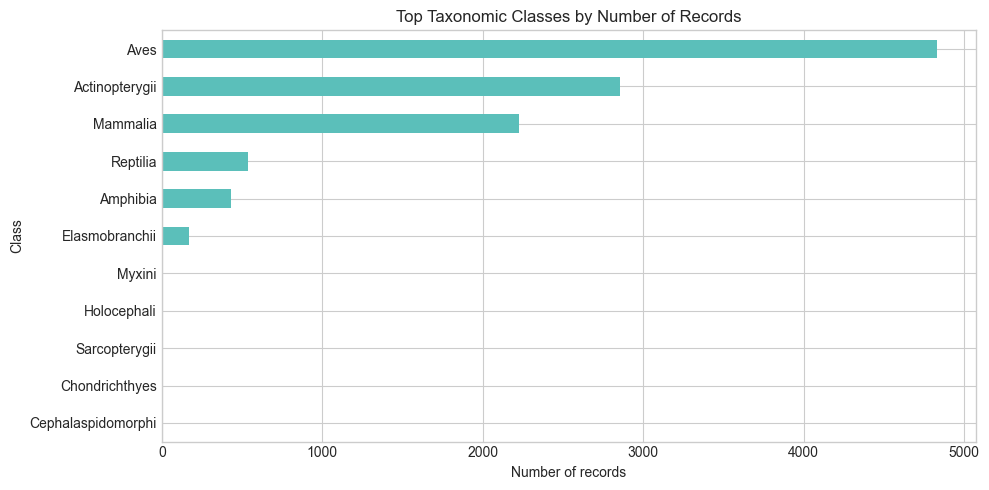

In [6]:
# Visualization 1: top classes by record count
top_classes = df['Class'].fillna('Unknown').value_counts().head(12)

fig, ax = plt.subplots(figsize=(10, 5))
top_classes.sort_values().plot(kind='barh', ax=ax, color='#5BBFBA')
ax.set_title('Top Taxonomic Classes by Number of Records')
ax.set_xlabel('Number of records')
ax.set_ylabel('Class')
plt.tight_layout()
plt.show()

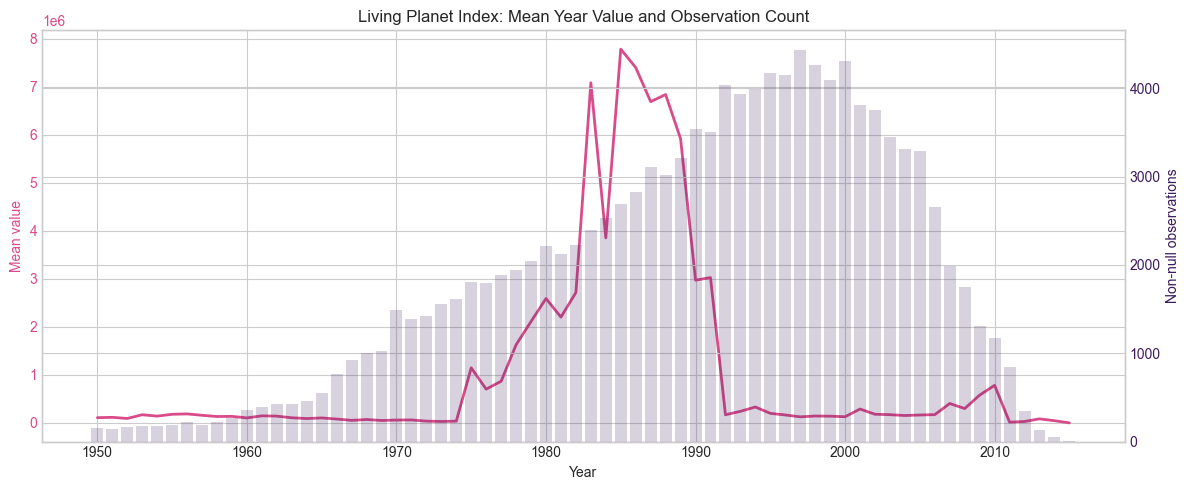

In [7]:
# Visualization 2: average observed value by year (across all rows)
year_numeric = df[year_cols].apply(pd.to_numeric, errors='coerce')
mean_by_year = year_numeric.mean(axis=0, skipna=True)
obs_count_by_year = year_numeric.notna().sum(axis=0)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(mean_by_year.index.astype(int), mean_by_year.values, color='#D94B8A', linewidth=2, label='Mean observed value')
ax1.set_xlabel('Year')
ax1.set_ylabel('Mean value', color='#D94B8A')
ax1.tick_params(axis='y', labelcolor='#D94B8A')

ax2 = ax1.twinx()
ax2.bar(obs_count_by_year.index.astype(int), obs_count_by_year.values, alpha=0.2, color='#3D1A5C', label='Observations')
ax2.set_ylabel('Non-null observations', color='#3D1A5C')
ax2.tick_params(axis='y', labelcolor='#3D1A5C')

ax1.set_title('Living Planet Index: Mean Year Value and Observation Count')
fig.tight_layout()
plt.show()

In [8]:
# Descriptive statistics for numeric columns
numeric_df = df.copy()
for c in ['Latitude', 'Longitude'] + year_cols:
    if c in numeric_df.columns:
        numeric_df[c] = pd.to_numeric(numeric_df[c], errors='coerce')

numeric_cols = numeric_df.select_dtypes(include=[np.number]).columns.tolist()
numeric_stats = numeric_df[numeric_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
numeric_stats.head(20)

,count,mean,std,min,5%,25%,50%,75%,95%,max
ID,11067.0,8030.877383,4.662898e+03,4.000000,797.300000,4691.500000,7863.00000,11356.50,17509.700000,1.832700e+04
Latitude,11067.0,23.677684,3.463093e+01,-78.193822,-38.078332,-3.505416,38.04167,49.75,64.000000,8.100000e+01
Longitude,11067.0,-8.748780,8.313146e+01,-179.715000,-138.140000,-75.992360,0.84417,31.75,145.761669,1.798333e+02
Specific_location,11067.0,0.501220,5.000211e-01,0.000000,0.000000,0.000000,1.00000,1.00,1.000000,1.000000e+00
1950,156.0,109504.799360,1.122651e+06,0.000000,0.000000,2.000000,31.50000,1025.00,78752.817500,1.399200e+07
1951,142.0,116478.029861,1.105680e+06,0.000000,0.000000,1.936750,28.24050,1370.00,95061.850000,1.314500e+07
1952,169.0,92786.715105,9.285391e+05,0.000000,0.000000,3.000000,32.00000,650.00,95195.536000,1.202800e+07
1953,173.0,170567.461728,1.416688e+06,0.000000,0.000000,2.000000,28.00000,520.00,96895.200000,1.512911e+07
1954,177.0,141766.256660,1.113406e+06,0.000000,0.000000,2.000000,29.00000,614.00,87029.872000,1.059300e+07
1955,188.0,180012.753532,1.550465e+06,0.000000,0.000000,2.750000,29.00000,366.25,106648.600000,1.799029e+07


In [9]:
# Descriptive statistics for non-numeric columns
categorical_cols = [c for c in df.columns if c not in numeric_cols]
categorical_stats = []

for c in categorical_cols:
    s = df[c]
    mode_vals = s.mode(dropna=True)
    categorical_stats.append({
        'column': c,
        'dtype': str(s.dtype),
        'non_null_count': int(s.notna().sum()),
        'missing_count': int(s.isna().sum()),
        'missing_pct': float(round(s.isna().mean() * 100, 2)),
        'unique_count': int(s.nunique(dropna=True)),
        'most_frequent_value': None if mode_vals.empty else str(mode_vals.iloc[0])
    })

categorical_stats_df = pd.DataFrame(categorical_stats).sort_values('unique_count', ascending=False)
categorical_stats_df.head(25)

,column,dtype,non_null_count,missing_count,missing_pct,unique_count,most_frequent_value
10,Location,object,11067,0,0.00,4762,United States and Canada
0,Binomial,object,11067,0,0.00,3456,Loxodonta_africana
9,Common_name,object,11067,0,0.00,3371,No common name
1,Reference,object,11067,0,0.00,2679,"{Sauer, 2012 #3261}"
6,Species,object,11067,0,0.00,2645,africana
23,Method,object,11067,0,0.00,2400,Unknown
5,Genus,object,11067,0,0.00,1816,Larus
22,Units,object,11067,0,0.00,1752,Number of individuals
8,Authority,object,11067,0,0.00,1638,"(Linnaeus, 1758)"
4,Family,object,11067,0,0.00,504,Anatidae


In [ ]:
# Unique values for each column (full, no truncation)
unique_values_by_column = {}
unique_values_records = []

for c in df.columns:
    values = sorted(df[c].dropna().astype(str).unique().tolist())
    unique_values_by_column[c] = values

    for v in values:
        unique_values_records.append({
            'column': c,
            'unique_value': v
        })

# Summary table (counts)
unique_values_summary_df = pd.DataFrame({
    'column': list(unique_values_by_column.keys()),
    'unique_count': [len(unique_values_by_column[c]) for c in unique_values_by_column.keys()]
}).sort_values('unique_count', ascending=False)

# Long table containing every unique value for every column
unique_values_long_df = pd.DataFrame(unique_values_records).sort_values(['column', 'unique_value'])

# Export complete unique values in two reusable formats
all_values_json_path = output_dir / 'living-planet-index-all-unique-values.json'
all_values_csv_path = output_dir / 'living-planet-index-all-unique-values.csv'

with open(all_values_json_path, 'w', encoding='utf-8') as f:
    json.dump(unique_values_by_column, f, ensure_ascii=False, indent=2)

unique_values_long_df.to_csv(all_values_csv_path, index=False)

print('Saved full unique values:')
print(f'- JSON: {all_values_json_path}')
print(f'- CSV : {all_values_csv_path}')

unique_values_summary_df.head(30)

,column,unique_count,preview_unique_values
0,ID,11067,"10, 100, 1000, 10010, 10013, 10015, 10016, 100..."
11,Location,4762,The eastern section is from Kanyemba to Rucko...
16,Longitude,3933,"-0.05, -0.052222, -0.09611, -0.1, -0.15111, -0..."
15,Latitude,3792,"-0.06667, -0.13611, -0.16667, -0.1925, -0.2375..."
1,Binomial,3456,"Abramis_brama, Abrothrix_longipilis, Abrothrix..."
10,Common_name,3371,"Abbott's booby, Abert's towhee, Acadian flycat..."
2,Reference,2679,"Abdelaziz et al. 2006, Chronique naturaliste p..."
7,Species,2645,"aalge, abacura, abbotti, abdominalis, abelii, ..."
27,Method,2400,Counting is a requirement and ocurs on two co...
78,2000,2370,"0.0, 0.0001, 0.0002, 0.0003, 0.0008, 0.001, 0...."


In [11]:
# Build export profile for the dataset explorer
profile = {
    'dataset': 'living-planet-index',
    'source_file': str(csv_path.name),
    'row_count': int(df.shape[0]),
    'column_count': int(df.shape[1]),
    'year_range': {'start': int(min(year_cols)), 'end': int(max(year_cols))},
    'columns': {}
}

for c in df.columns:
    s = df[c]
    values = unique_values_by_column[c]

    col_profile = {
        'dtype': str(s.dtype),
        'missing_count': int(s.isna().sum()),
        'missing_pct': float(round(s.isna().mean() * 100, 4)),
        'unique_count': int(len(values)),
        'unique_values': values
    }

    if c in numeric_cols:
        num = pd.to_numeric(df[c], errors='coerce')
        col_profile['numeric_summary'] = {
            'min': None if num.dropna().empty else float(num.min()),
            'max': None if num.dropna().empty else float(num.max()),
            'mean': None if num.dropna().empty else float(num.mean()),
            'median': None if num.dropna().empty else float(num.median())
        }

    profile['columns'][c] = col_profile

profile_path = output_dir / 'living-planet-index-profile.json'
with open(profile_path, 'w', encoding='utf-8') as f:
    json.dump(profile, f, ensure_ascii=False, indent=2)

profile_path

PosixPath('/Users/mjdiepeveen/Documents/sciencedisco/wwf-discovery-day/documentation/dataset-profiles/living-planet-index-profile.json')

In [ ]:
# Show all possible values for a selected column
column_to_inspect = 'Class'  # change this to any column name

if column_to_inspect not in unique_values_by_column:
    raise ValueError(f"Column '{column_to_inspect}' not found.")

all_values_for_column = pd.DataFrame({
    'column': column_to_inspect,
    'unique_value': unique_values_by_column[column_to_inspect]
})

print(f"{column_to_inspect}: {len(all_values_for_column)} unique values")
all_values_for_column

['ID',
 'Binomial',
 'Reference',
 'Class',
 'Order',
 'Family',
 'Genus',
 'Species',
 'Subspecies',
 'Authority',
 'Common_name',
 'Location',
 'Country',
 'All_countries',
 'Region']